In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

# Define paths based on your structure
base_dir = Path("E:/drone-human-car-detection/data/VisDrone/VisDrone_Dataset")
train_images = base_dir / "VisDrone2019-DET-train" / "images"
train_labels = base_dir / "VisDrone2019-DET-train" / "labels"

img_count = len(list(train_images.glob("*.jpg")))
lbl_count = len(list(train_labels.glob("*.txt")))

print(f"Training Images: {img_count}")
print(f"Training Labels: {lbl_count}")
if img_count == lbl_count:
    print("Dataset verification passed: Image and label counts match.")
else:
    print("Warning: Mismatch in image and label counts!")


Training Images: 6471
Training Labels: 6471
Dataset verification passed: Image and label counts match.


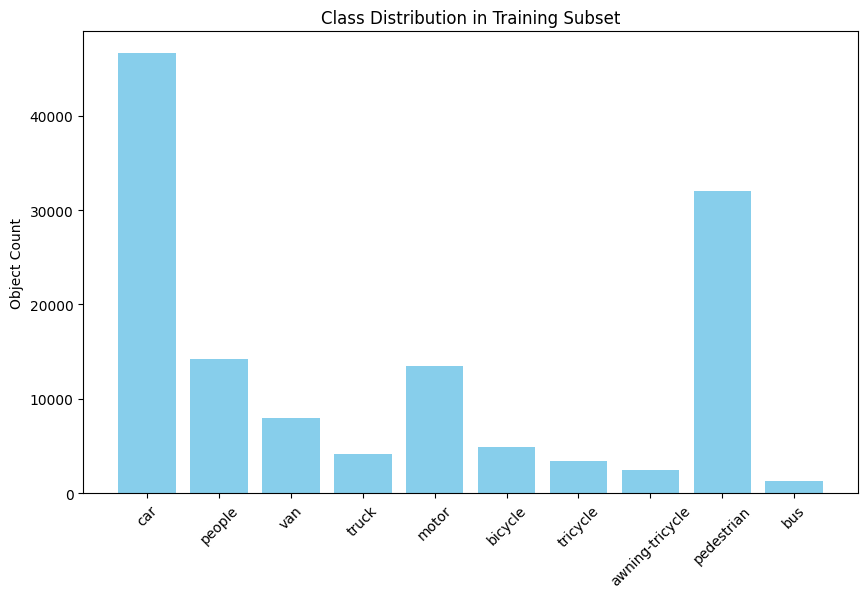

In [2]:
from collections import Counter
import pandas as pd

class_names = {
    0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van',
    5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'
}

class_counts = Counter()

# Read a sample of labels to build the distribution (reading all might take a moment)
for label_file in list(train_labels.glob("*.txt"))[:2000]: 
    with open(label_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            cls_id = int(line.split()[0])
            class_counts[class_names.get(cls_id, 'unknown')] += 1

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title("Class Distribution in Training Subset")
plt.xticks(rotation=45)
plt.ylabel("Object Count")
plt.show()


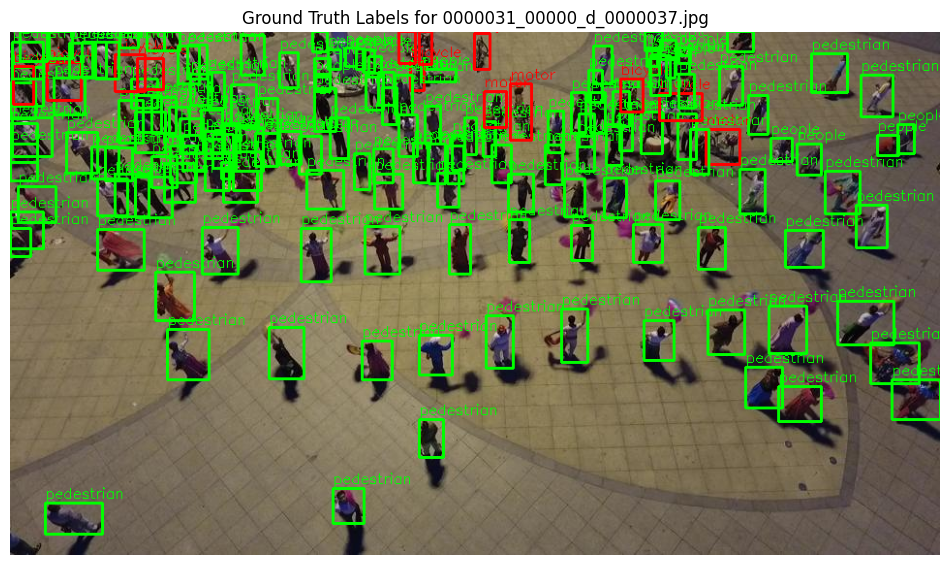

In [7]:
# Select a random image to visualize
sample_img_path = list(train_images.glob("*.jpg"))[20] # Grab the 21th image
sample_lbl_path = train_labels / f"{sample_img_path.stem}.txt"

img = cv2.imread(str(sample_img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

with open(sample_lbl_path, 'r') as f:
    lines = f.readlines()

for line in lines:
    parts = line.split()
    cls_id = int(parts[0])
    
    # YOLO format: class x_center y_center width height (normalized)
    x_center, y_center, width, height = map(float, parts[1:])
    
    # Convert normalized to pixel coordinates
    x1 = int((x_center - width/2) * w)
    y1 = int((y_center - height/2) * h)
    x2 = int((x_center + width/2) * w)
    y2 = int((y_center + height/2) * h)
    
    # Draw green boxes for humans (0,1), blue for cars (3), red for others
    if cls_id in [0, 1]:
        color = (0, 255, 0)
    elif cls_id == 3:
        color = (0, 0, 255)
    else:
        color = (255, 0, 0)
        
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, class_names[cls_id], (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis('off')
plt.title(f"Ground Truth Labels for {sample_img_path.name}")
plt.show()
